# Complaint Volume Forecasting (90-Day Horizon)

## Objective
Build a reproducible forecasting workflow to predict daily complaints for the next 90 days after the final date in the provided dataset.

## Project layout
- `data/` — raw Excel inputs
- `src/` — reusable feature engineering and forecasting functions
- `results/` — tables, figures, and forecast outputs
- this notebook — EDA, model comparison, and commentary

## Approach (high level)
1. Load, clean, and validate the daily records data.
2. Exploratory Data Analysis (EDA): summary tables + figures with explanatory notes.
3. Decompose complaints with STL into tendency / period / noise.
4. Train component-specific HGB models using correlation-selected causal features.
5. Compare candidate models against **naive baselines** and against a direct HGB trained on raw table features with **no** signal decomposition.
6. Select the better candidate model on a 90-day holdout, check the same four models on a 180-day holdout, and produce the final 90-day forecast.

## Key modelling decisions
- Holdout comparison includes naive baselines plus two candidate models:
  - `Naive_LastValue` (repeat the last observed day)
  - `SeasonalNaive_Weekly` (repeat the last 7-day cycle)
  - `STL_ComponentHGB_SelectedFeatures`
  - `HGB_RawTableFeatures`
- Raw-table HGB uses lag-1 operational covariates (`staffing`, `backlog`, `media`, `channel_mix`) plus known calendar signals.
- Component HGB uses STL decomposition + top correlated features per component (including causal `roll28_mean` / `roll28_std`).
- Future unknown exogenous values are handled by persisting last known lagged covariates.
- Winner among candidates is by **90-day** holdout MAE; a **180-day** holdout is a robustness check only. Naive baselines are the reference bar, not production candidates.
- Residual-bootstrap paths restore high-frequency fluctuation on top of the STL structure for scenario realism.


In [18]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL

# Ensure project root is importable when the notebook kernel cwd is the repo folder
BASE_DIR = Path.cwd().resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from src.forecasting import (
    build_component_feature_frame,
    build_raw_table_feature_frame,
    component_hgb_forecast,
    generate_residual_bootstrap_paths,
    hgb_raw_table_forecast,
    naive_forecast,
    score_forecast,
    seasonal_naive_forecast,
    select_component_features,
    stl_component_targets,
)

np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 50)


In [19]:
# Reproducible paths relative to the project root
DATA_DIR = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

EXCEL_PATH = DATA_DIR / 'Principle_Data_Scientist_Tech_Assessment.xlsx'
EXCEL_FALLBACK = DATA_DIR / 'Principle_Data_Scientist_Tech_Assessment_copy.xlsx'

# Prefer the original workbook; fall back if the file is locked (e.g. open in Excel)
if EXCEL_PATH.exists():
    try:
        pd.read_excel(EXCEL_PATH, sheet_name='daily records', nrows=1)
    except PermissionError:
        assert EXCEL_FALLBACK.exists(), f'Excel locked and fallback missing: {EXCEL_FALLBACK}'
        EXCEL_PATH = EXCEL_FALLBACK
else:
    assert EXCEL_FALLBACK.exists(), f'Excel file not found at {EXCEL_PATH}'
    EXCEL_PATH = EXCEL_FALLBACK

print('Excel:', EXCEL_PATH)
print('Results:', RESULTS_DIR)
EXCEL_PATH


Excel: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\data\Principle_Data_Scientist_Tech_Assessment.xlsx
Results: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results


WindowsPath('C:/Users/liyuan.liu/OneDrive - CPI/Learning and Development/Technical-Assessment-LiyuanLIU/data/Principle_Data_Scientist_Tech_Assessment.xlsx')

In [20]:
df = pd.read_excel(EXCEL_PATH, sheet_name='daily records')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').drop_duplicates(subset=['date']).set_index('date')

# Daily frequency is required for step-ahead forecasting
full_index = pd.date_range(df.index.min(), df.index.max(), freq='D')
df = df.reindex(full_index)

# Keep target clean; simple interpolation for occasional missing targets
if df['complaints'].isna().any():
    df['complaints'] = df['complaints'].interpolate(method='time').ffill().bfill()

df.index.name = 'date'
df[['complaints']].head()

C:\Users\liyuan.liu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Sparkline Group extension is not supported and will be removed
  warn(msg)


,complaints
date,
2023-01-01,75.0
2023-01-02,80.0
2023-01-03,84.0
2023-01-04,83.0
2023-01-05,70.0


## Exploratory Data Analysis (EDA)

This section builds intuition for forecasting by answering:
- **what the data looks like**
- **what quality issues matter**
- **what patterns drive forecasting**

### EDA summary

**What EDA shows**
- Daily complaints (2023–2025) are noisy and high-frequency: mean ≈ 80, std ≈ 25, CV ≈ 0.31 (day-to-day swings are about 31% of the average level).
- Autocorr at lag-1 and lag-7 (~0.41) points to short-term persistence **and** a weekly rhythm.
- Weekday means differ (Mon–Wed higher, Thu/Fri lower) → useful for staffing, but within-day std is still large.
- Monthly averages drift over time → the medium-term level is not static. **Winter months tend to have more complaints than summer.**
- Operational features (staffing, backlog) correlate moderately with complaints; `centered_7d_mean` looks strong but leaks future information, so it is diagnostic only.
- 28-day mean tracks level; 28-day std shows changing volatility.

### Why STL is used for this complaint forecasting problem

**What STL is**
- STL (Seasonal-Trend decomposition using Loess) splits complaints into three additive parts. Here we use weekly `period=7`:
  - **Tendency** = slow level / medium-term drift (including longer seasonal shifts such as winter vs summer)
  - **Period** = repeating weekly seasonality
  - **Noise** = irregular leftover
- In this data, noise std is similar in size to tendency std → irregular swings are a large share of the signal.

**Why STL matters here**
- EDA shows level, weekly pattern, and noise are mixed; STL separates them so each can use different features (`roll28_mean` → tendency, calendar → period, `roll28_std`/ops → noise).
- Matches the business split: tendency + period for capacity planning; noise for day-to-day uncertainty.
- Explains why point forecasts look smoother than history, and why we restore realistic fluctuation with residual bootstrap on top of the deterministic structure.

In [21]:
# --- EDA Table 1: Dataset overview & data quality ---
# Note: after reindexing to a continuous daily calendar, missing rows become explicit NaNs.

eda_raw_nulls = df.isna().sum()
overview = pd.DataFrame(
    {
        'metric': [
            'start_date',
            'end_date',
            'n_days_after_reindex',
            'missing_complaints',
            'missing_staffing_level_fte',
            'missing_backlog_days',
            'missing_channel_mix_index',
            'mean_complaints',
            'std_complaints',
            'cv_complaints',
            'autocorr_lag1',
            'autocorr_lag7',
        ],
        'value': [
            str(df.index.min().date()),
            str(df.index.max().date()),
            len(df),
            int(eda_raw_nulls.get('complaints', 0)),
            int(eda_raw_nulls.get('staffing_level_fte', 0)),
            int(eda_raw_nulls.get('backlog_days', 0)),
            int(eda_raw_nulls.get('channel_mix_index', 0)),
            round(float(df['complaints'].mean()), 2),
            round(float(df['complaints'].std()), 2),
            round(float(df['complaints'].std() / df['complaints'].mean()), 3),
            round(float(df['complaints'].autocorr(1)), 3),
            round(float(df['complaints'].autocorr(7)), 3),
        ],
    }
)

overview_csv = RESULTS_DIR / 'eda_overview.csv'
overview.to_csv(overview_csv, index=False)
print('Saved:', overview_csv)
display(overview)

print(
    """
Explanatory notes (data quality):
- Continuous daily indexing exposes calendar gaps so forecasting does not silently skip days.
- Missing complaints/exogenous fields are filled later by time interpolation for modelling.
- CV ~0.3 and moderate lag-1/lag-7 autocorrelation indicate a noisy series with weekly structure.
"""
)

Saved: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\eda_overview.csv


,metric,value
0,start_date,2023-01-01
1,end_date,2025-12-31
2,n_days_after_reindex,1096
3,missing_complaints,0
4,missing_staffing_level_fte,74
5,missing_backlog_days,64
6,missing_channel_mix_index,64
7,mean_complaints,80.1
8,std_complaints,25.05
9,cv_complaints,0.313



Explanatory notes (data quality):
- Continuous daily indexing exposes calendar gaps so forecasting does not silently skip days.
- Missing complaints/exogenous fields are filled later by time interpolation for modelling.
- CV ~0.3 and moderate lag-1/lag-7 autocorrelation indicate a noisy series with weekly structure.



In [22]:
# --- EDA Table 2: Day-of-week, monthly, and yearly patterns (capacity planning) ---
eda_tmp = df.copy()
eda_tmp['dow'] = eda_tmp.index.dayofweek
eda_tmp['dow_name'] = eda_tmp.index.day_name()
eda_tmp['month'] = eda_tmp.index.month
eda_tmp['month_name'] = eda_tmp.index.month_name()
eda_tmp['year'] = eda_tmp.index.year

# Day-of-week
dow_summary = (
    eda_tmp.groupby(['dow', 'dow_name'], as_index=False)['complaints']
    .agg(mean='mean', median='median', std='std', n='count')
    .sort_values('dow')
)
dow_summary['mean'] = dow_summary['mean'].round(1)
dow_summary['median'] = dow_summary['median'].round(1)
dow_summary['std'] = dow_summary['std'].round(1)

# Monthly (across all years)
month_summary = (
    eda_tmp.groupby(['month', 'month_name'], as_index=False)['complaints']
    .agg(mean='mean', median='median', std='std', n='count')
    .sort_values('month')
)
month_summary['mean'] = month_summary['mean'].round(1)
month_summary['median'] = month_summary['median'].round(1)
month_summary['std'] = month_summary['std'].round(1)

# Yearly
year_summary = (
    eda_tmp.groupby(['year'], as_index=False)['complaints']
    .agg(mean='mean', median='median', std='std', n='count')
    .sort_values('year')
)
year_summary['mean'] = year_summary['mean'].round(1)
year_summary['median'] = year_summary['median'].round(1)
year_summary['std'] = year_summary['std'].round(1)

dow_csv = RESULTS_DIR / 'eda_day_of_week_summary.csv'
month_csv = RESULTS_DIR / 'eda_month_summary.csv'
year_csv = RESULTS_DIR / 'eda_year_summary.csv'
dow_summary.to_csv(dow_csv, index=False)
month_summary.to_csv(month_csv, index=False)
year_summary.to_csv(year_csv, index=False)

print('Saved:', dow_csv)
print('Day-of-week pattern:')
display(dow_summary.drop(columns=['dow']))

print('Saved:', month_csv)
print('Monthly pattern:')
display(month_summary.drop(columns=['month']))

print('Saved:', year_csv)
print('Yearly pattern:')
display(year_summary)


Saved: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\eda_day_of_week_summary.csv
Day-of-week pattern:


,dow_name,mean,median,std,n
0,Monday,86.1,84.0,23.9,157
1,Tuesday,85.2,81.0,25.3,157
2,Wednesday,84.5,80.0,24.2,157
3,Thursday,74.4,71.0,23.8,156
4,Friday,72.3,70.0,23.2,156
5,Saturday,76.1,72.5,26.5,156
6,Sunday,82.1,75.0,24.9,157


Saved: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\eda_month_summary.csv
Monthly pattern:


,month_name,mean,median,std,n
0,January,88.2,83.0,19.8,93
1,February,90.4,86.0,21.3,85
2,March,83.9,80.0,18.8,93
3,April,79.4,74.0,22.9,90
4,May,73.4,69.0,23.2,93
5,June,69.6,62.5,24.0,90
6,July,65.8,62.0,22.1,93
7,August,67.9,65.5,22.8,93
8,September,71.9,69.5,25.4,90
9,October,84.3,79.0,25.6,93


Saved: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\eda_year_summary.csv
Yearly pattern:


,year,mean,median,std,n
0,2023,66.7,68.0,13.6,365
1,2024,78.2,77.5,21.3,366
2,2025,95.5,94.0,28.8,365


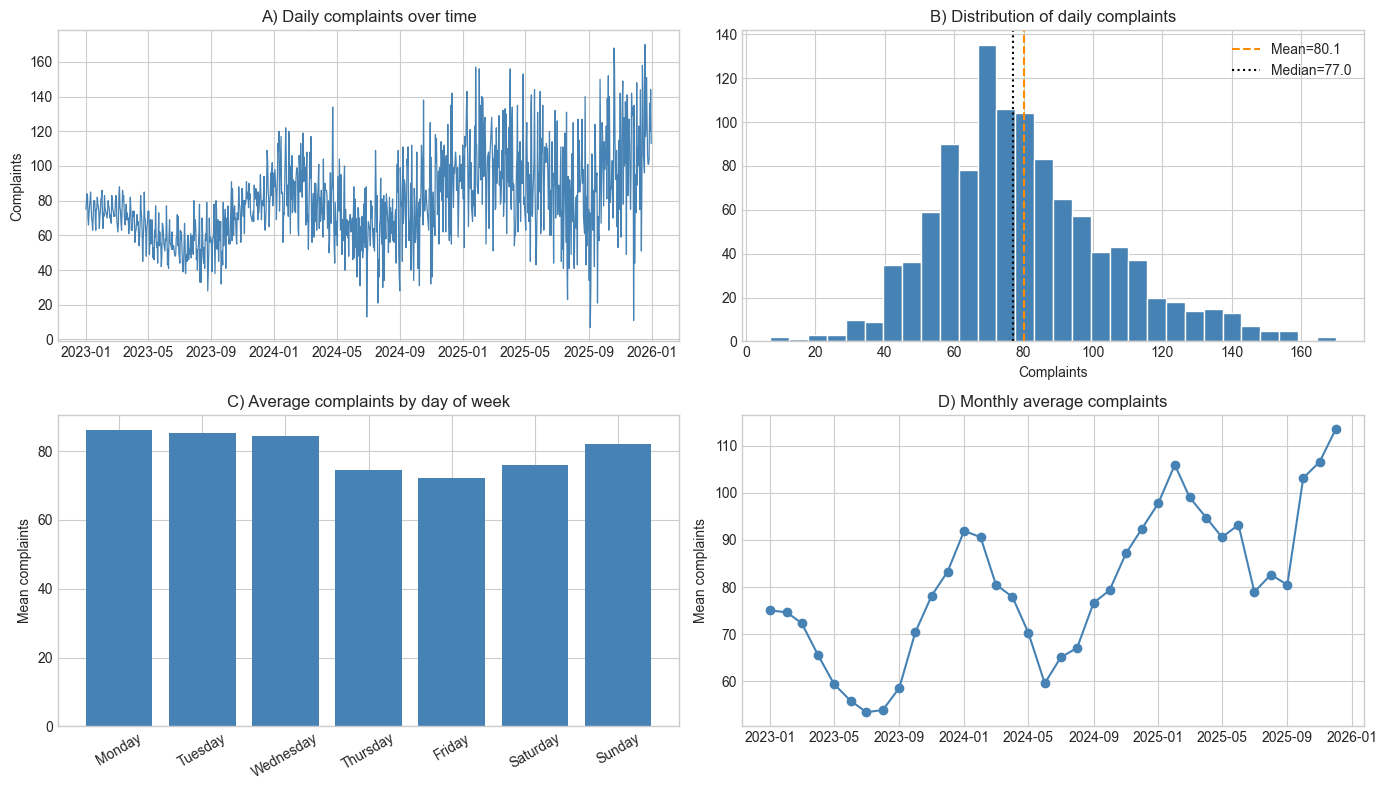

Saved: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\eda_overview_figures.png


In [23]:
# --- EDA Figures: time series, distribution, weekly pattern, monthly trend ---
y = df['complaints'].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Full history
axes[0, 0].plot(y.index, y.values, color='steelblue', linewidth=0.9)
axes[0, 0].set_title('A) Daily complaints over time')
axes[0, 0].set_ylabel('Complaints')

# 2) Distribution
axes[0, 1].hist(y.dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0, 1].axvline(y.mean(), color='darkorange', linestyle='--', label=f'Mean={y.mean():.1f}')
axes[0, 1].axvline(y.median(), color='black', linestyle=':', label=f'Median={y.median():.1f}')
axes[0, 1].set_title('B) Distribution of daily complaints')
axes[0, 1].set_xlabel('Complaints')
axes[0, 1].legend()

# 3) Day-of-week means
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_plot = dow_summary.set_index('dow_name').loc[dow_order]
axes[1, 0].bar(dow_plot.index, dow_plot['mean'], color='steelblue')
axes[1, 0].set_title('C) Average complaints by day of week')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_ylabel('Mean complaints')

# 4) Monthly averages
monthly = y.resample('MS').mean()
axes[1, 1].plot(monthly.index, monthly.values, marker='o', color='steelblue')
axes[1, 1].set_title('D) Monthly average complaints')
axes[1, 1].set_ylabel('Mean complaints')

plt.tight_layout()
eda_overview_png = RESULTS_DIR / 'eda_overview_figures.png'
fig.savefig(eda_overview_png, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', eda_overview_png)


### feature analysis 
- The strongest correlations often come from smoothed level proxies (e.g. `centered_7d_mean`), which can leak future information — keep them diagnostic only, not for true forecasting.
- Operational features (staffing / backlog) are more likely to help explain residual noise than the full seasonal structure.
- Rising and falling 28-day volatility confirms the series is noisy, so feature engineering is needed: add causal rolling features, then correlate both raw and derived features with the STL components (tendency / period / noise) to support modelling and communication.


Saved: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\eda_feature_correlations.csv


,corr_with_complaints
centered_7d_mean,0.677
staffing_level_fte,0.394
backlog_days,0.277
bank_holiday_flag,0.056
media_mentions,-0.038
is_weekend,-0.022
channel_mix_index,0.015


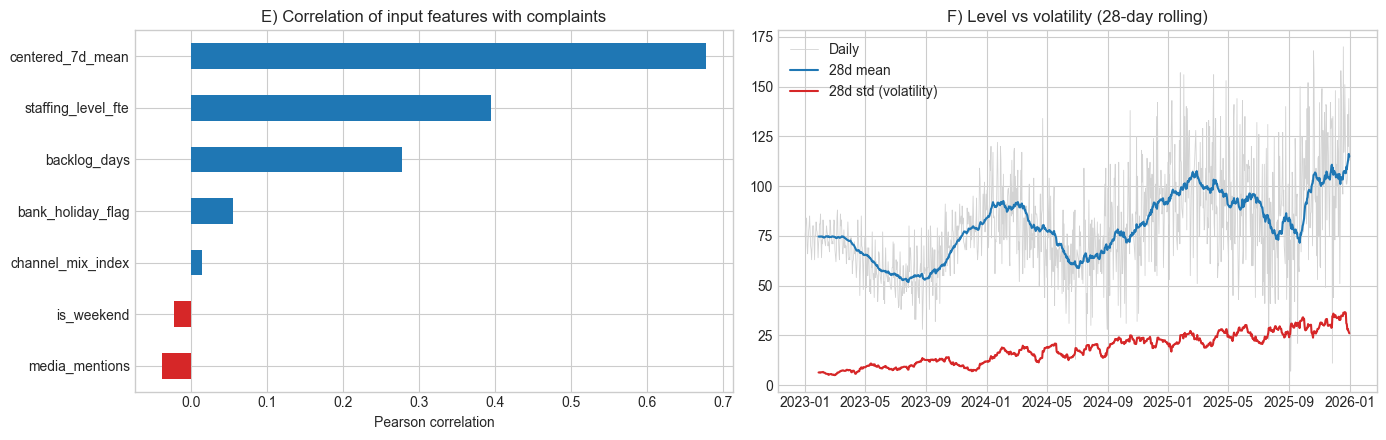

Saved: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\eda_relationships_volatility.png


In [24]:
# --- EDA: feature relationships with complaints + rolling volatility ---
feature_cols_eda = [
    'is_weekend',
    'bank_holiday_flag',
    'staffing_level_fte',
    'backlog_days',
    'media_mentions',
    'channel_mix_index',
    'centered_7d_mean',
]

corr_eda = (
    df[feature_cols_eda + ['complaints']]
    .corr(numeric_only=True)['complaints']
    .drop('complaints')
    .sort_values(key=np.abs, ascending=False)
    .to_frame('corr_with_complaints')
    .round(3)
)

corr_eda_csv = RESULTS_DIR / 'eda_feature_correlations.csv'
corr_eda.to_csv(corr_eda_csv)
print('Saved:', corr_eda_csv)
display(corr_eda)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Correlation bars
corr_sorted = corr_eda['corr_with_complaints'].sort_values()
colors = ['#d62728' if v < 0 else '#1f77b4' for v in corr_sorted.values]
corr_sorted.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('E) Correlation of input features with complaints')
axes[0].set_xlabel('Pearson correlation')

# Rolling mean/std to show noise vs level
roll_mean = y.rolling(28).mean()
roll_std = y.rolling(28).std()
axes[1].plot(y.index, y.values, color='lightgray', linewidth=0.6, label='Daily')
axes[1].plot(roll_mean.index, roll_mean.values, color='tab:blue', label='28d mean')
axes[1].plot(roll_std.index, roll_std.values, color='tab:red', label='28d std (volatility)')
axes[1].set_title('F) Level vs volatility (28-day rolling)')
axes[1].legend()

plt.tight_layout()
eda_rel_png = RESULTS_DIR / 'eda_relationships_volatility.png'
fig.savefig(eda_rel_png, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', eda_rel_png)



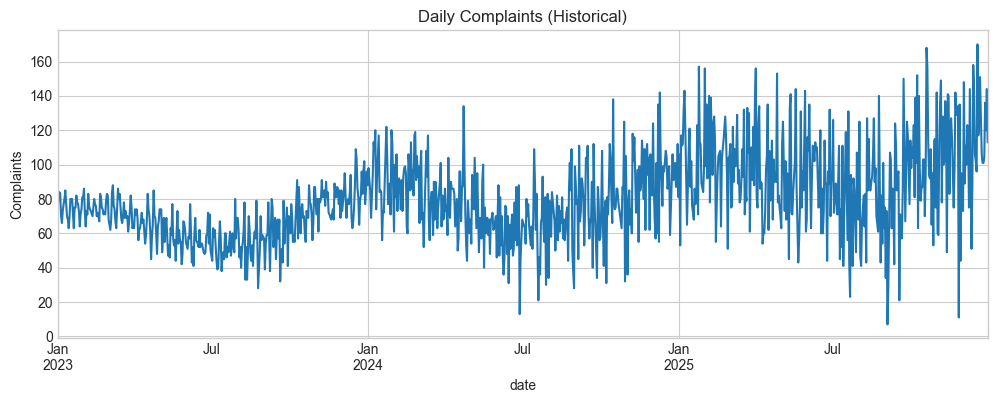

Noise snapshot: n=1096, mean=80.1, std=25.1, CV=0.31, autocorr_1=0.41, autocorr_7=0.42


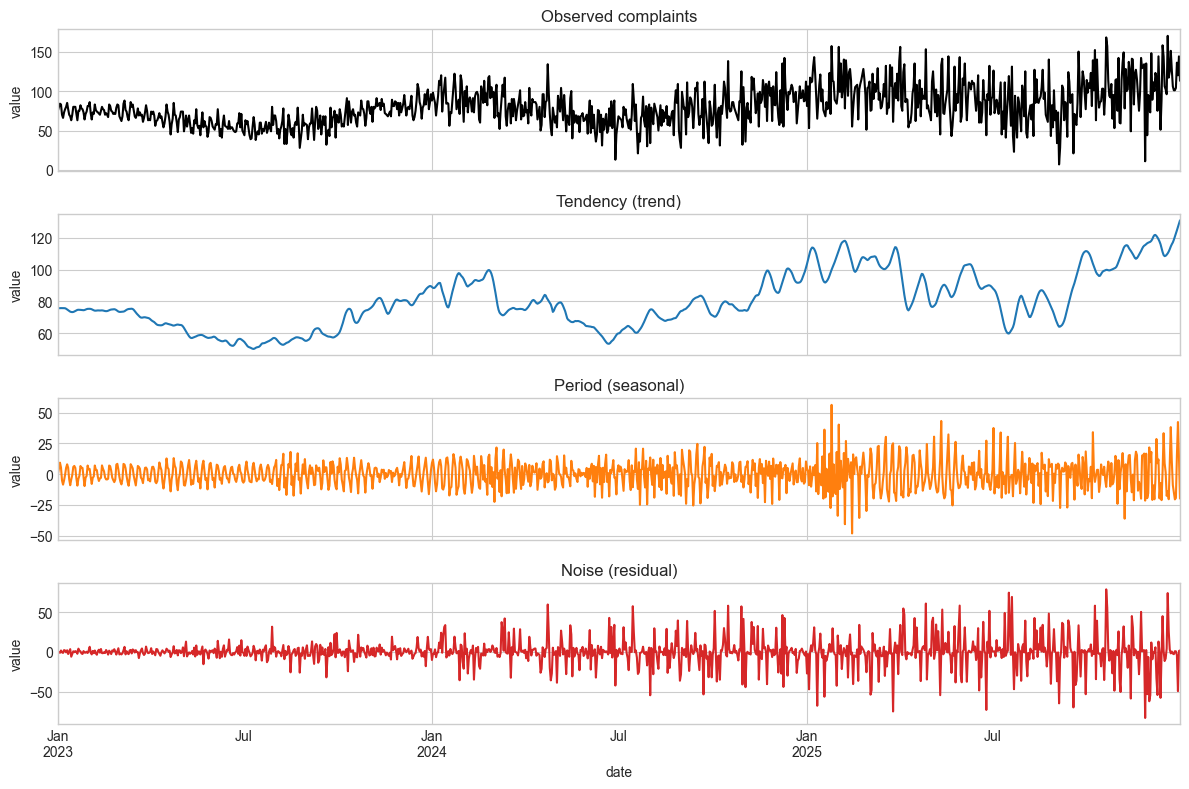

STL component summary saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\stl_component_summary.csv


,mean,std
observed,80.098996,25.050931
tendency,80.172168,17.482358
period,0.022015,11.082965
noise,-0.095186,17.621724


In [8]:
target_preview = df['complaints'].astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
target_preview.plot(ax=ax)
ax.set_title('Daily Complaints (Historical)')
ax.set_ylabel('Complaints')
plt.show()

print(
    f'Noise snapshot: n={len(target_preview)}, '
    f'mean={target_preview.mean():.1f}, std={target_preview.std():.1f}, '
    f'CV={target_preview.std() / target_preview.mean():.2f}, '
    f'autocorr_1={target_preview.autocorr(1):.2f}, '
    f'autocorr_7={target_preview.autocorr(7):.2f}'
)

# STL decomposition into tendency (trend), period (seasonal), and noise (residual)
stl_preview = STL(target_preview, period=7, robust=True).fit()
components_df = pd.DataFrame(
    {
        'observed': target_preview,
        'tendency': stl_preview.trend,
        'period': stl_preview.seasonal,
        'noise': stl_preview.resid,
    },
    index=target_preview.index,
)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
components_df['observed'].plot(ax=axes[0], color='black', title='Observed complaints')
components_df['tendency'].plot(ax=axes[1], color='tab:blue', title='Tendency (trend)')
components_df['period'].plot(ax=axes[2], color='tab:orange', title='Period (seasonal)')
components_df['noise'].plot(ax=axes[3], color='tab:red', title='Noise (residual)')
for ax in axes:
    ax.set_ylabel('value')
plt.tight_layout()
plt.show()

stl_component_summary = components_df.agg(['mean', 'std']).T
stl_summary_csv = RESULTS_DIR / 'stl_component_summary.csv'
stl_component_summary.to_csv(stl_summary_csv)
print(f'STL component summary saved to: {stl_summary_csv}')
display(stl_component_summary)

Dominant frequencies in the STL seasonal component:


,frequency_per_day,period_days,power,power_share_pct
0,0.143248,6.980892,6.909632e+06,9.37
1,0.146898,6.807453,4.707029e+06,6.39
2,0.141423,7.070968,3.911042e+06,5.31
3,0.142336,7.025641,3.059523e+06,4.15
4,0.144161,6.936709,2.528988e+06,3.43
5,0.424270,2.356989,2.285616e+06,3.10
6,0.418796,2.387800,2.106323e+06,2.86
7,0.147810,6.765432,2.093294e+06,2.84


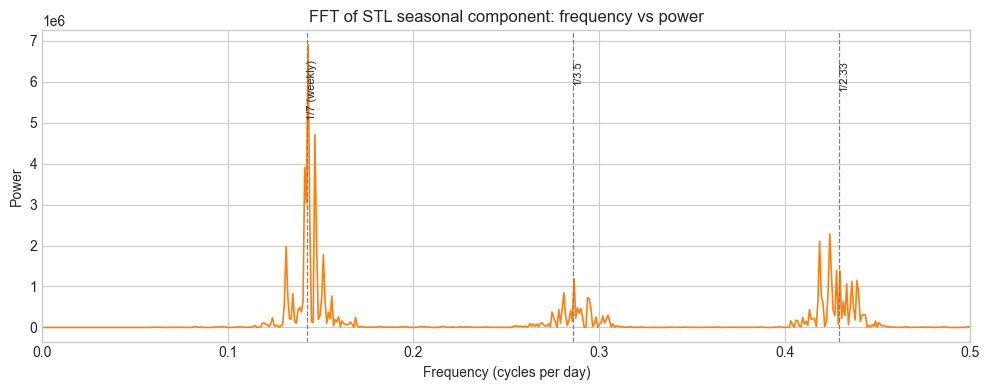

Saved: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\eda_fft_seasonal_component.png


In [25]:
# --- FFT on the STL seasonal component only (diagnostic: which cycle lengths dominate) ---
seasonal_signal = components_df['period'].dropna()
seasonal_values = seasonal_signal.to_numpy() - seasonal_signal.mean()

n_seasonal = len(seasonal_values)
seasonal_power = np.abs(np.fft.rfft(seasonal_values)) ** 2
seasonal_freqs = np.fft.rfftfreq(n_seasonal, d=1.0)  # cycles per day

keep = seasonal_freqs > 0
seasonal_fft = (
    pd.DataFrame(
        {
            'frequency_per_day': seasonal_freqs[keep],
            'period_days': 1.0 / seasonal_freqs[keep],
            'power': seasonal_power[keep],
        }
    )
    .sort_values('power', ascending=False)
    .reset_index(drop=True)
)
seasonal_fft['power_share_pct'] = (
    100 * seasonal_fft['power'] / seasonal_fft['power'].sum()
).round(2)

print('Dominant frequencies in the STL seasonal component:')
display(seasonal_fft.head(8))

# Frequency (cycles/day) vs power — weekly cycle is at 1/7 ≈ 0.143
plot_df = seasonal_fft.sort_values('frequency_per_day')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df['frequency_per_day'], plot_df['power'], color='tab:orange', linewidth=1.2)
for period_days, label in ((7.0, '1/7 (weekly)'), (3.5, '1/3.5'), (2.33, '1/2.33')):
    f = 1.0 / period_days
    ax.axvline(f, color='gray', linestyle='--', linewidth=0.9)
    ax.text(f, ax.get_ylim()[1] * 0.9, label, rotation=90, va='top', fontsize=8)
ax.set_xlim(0, 0.5)  # up to Nyquist for daily data
ax.set_xlabel('Frequency (cycles per day)')
ax.set_ylabel('Power')
ax.set_title('FFT of STL seasonal component: frequency vs power')
plt.tight_layout()
seasonal_fft_png = RESULTS_DIR / 'eda_fft_seasonal_component.png'
fig.savefig(seasonal_fft_png, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', seasonal_fft_png)


### STL decomposition figure

**Observed**
- **Observed:** daily complaints are high-frequency and noisy (roughly 40–170), with clear spikes on top of a changing level.
- **Tendency:** the smooth level falls through early/mid-2023, then rises through 2024–2025 — this is the medium-term drift useful for capacity planning.
- **Period:** a repeating weekly wave around zero; the amplitude grows later in the sample (especially into 2025), so weekday swings become larger over time.
- **Noise:** residuals are centred near zero, but their spread increases over time — later years are more volatile than 2023.

**Links to modelling**
- Tendency → model with causal level features such as `roll28_mean`.
- Period → model with calendar features (`dow_sin` / `dow_cos`, weekend).
- Noise → model with volatility / operational drivers (`roll28_std`, staffing, backlog); also motivates residual-bootstrap scenarios.
- Rising residual variance explains why point forecasts look smoother than history, and why a single static noise assumption is too weak.
- Each component has a separate target and separately selected inputs; there is no one-size-fits-all feature set.
- `roll28_mean` is causal (past 28 complaints only) and is expected to help tendency.
- `roll28_std` is causal and is expected to help noise by representing recent volatility.
- Source `centered_7d_mean` remains excluded because it uses future observations.


Selected features by STL component:


,component,rank,selected_feature
0,tendency,1,roll7_mean
1,tendency,2,roll28_mean
2,tendency,3,time_idx
3,tendency,4,roll28_std
4,tendency,5,lag_1
5,tendency,6,staffing_level_fte_lag1
6,tendency,7,doy_cos
7,tendency,8,lag_7
8,period,1,dow_cos
9,period,2,lag_7


Correlation table saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\stl_component_feature_correlations.csv
Selected-feature table saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\stl_component_selected_features.csv


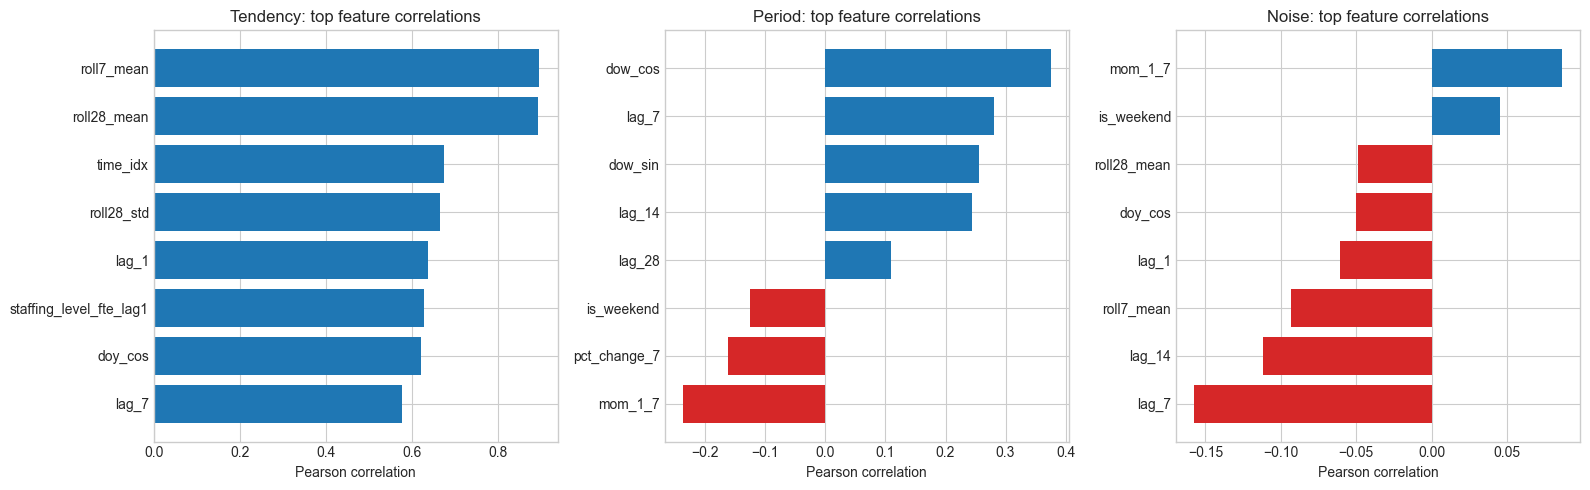

In [26]:
# --- STL component correlations and component-specific feature selection ---
# Causal versions are used: roll28_mean/std are shifted by one day in build_feature_frame.
component_exog_cols = [
    'staffing_level_fte',
    'backlog_days',
    'media_mentions',
    'channel_mix_index',
    'bank_holiday_flag',
]
component_exog = df[component_exog_cols].copy()
component_features = build_component_feature_frame(df['complaints'], component_exog)
component_targets = stl_component_targets(df['complaints'], period=7)
selected_component_features, component_correlations = select_component_features(
    component_features,
    component_targets,
    top_n=8,
)

component_correlations_csv = RESULTS_DIR / 'stl_component_feature_correlations.csv'
component_correlations.to_csv(component_correlations_csv, index=False)

selected_table = pd.DataFrame(
    [(component, rank + 1, feature) for component, features in selected_component_features.items() for rank, feature in enumerate(features)],
    columns=['component', 'rank', 'selected_feature'],
)
selected_features_csv = RESULTS_DIR / 'stl_component_selected_features.csv'
selected_table.to_csv(selected_features_csv, index=False)

print('Selected features by STL component:')
display(selected_table)
print(f'Correlation table saved to: {component_correlations_csv}')
print(f'Selected-feature table saved to: {selected_features_csv}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
for ax, component in zip(axes, ['tendency', 'period', 'noise']):
    plot_df = component_correlations[component_correlations['component'] == component].head(8).sort_values('pearson_correlation')
    colors = ['#d62728' if value < 0 else '#1f77b4' for value in plot_df['pearson_correlation']]
    ax.barh(plot_df['feature'], plot_df['pearson_correlation'], color=colors)
    ax.set_title(f'{component.title()}: top feature correlations')
    ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


In [27]:
# Holdout design: use final 90 days as pseudo-future
# Comparison: naive baselines vs STL component HGB vs direct raw-table HGB
horizon = 90
target = df['complaints'].astype(float)

train = target.iloc[:-horizon]
valid = target.iloc[-horizon:]

exog_cols = [
    'staffing_level_fte',
    'backlog_days',
    'media_mentions',
    'channel_mix_index',
    'bank_holiday_flag',
    'is_weekend',
]
exog_all = df[exog_cols].copy()

# Naive baselines (must beat these before claiming modelling value)
pred_naive = naive_forecast(train, horizon=horizon)
metrics_naive = score_forecast(valid, pred_naive)
pred_snaive = seasonal_naive_forecast(train, horizon=horizon, season=7)
metrics_snaive = score_forecast(valid, pred_snaive)

# A) Direct HGB on raw table features (no STL decomposition)
pred_raw_hgb = hgb_raw_table_forecast(train, exog_hist=exog_all.loc[train.index], horizon=horizon)
metrics_raw_hgb = score_forecast(valid, pred_raw_hgb)

# B) STL component HGB with correlation-selected features
pred_component_hgb, component_holdout_forecast, component_holdout_corr, component_holdout_features = component_hgb_forecast(
    train,
    exog_hist=exog_all.loc[train.index],
    horizon=horizon,
    period=7,
    top_n=8,
)
metrics_component_hgb = score_forecast(valid, pred_component_hgb)

print('Raw-table HGB features:')
print(', '.join(build_raw_table_feature_frame(train, exog_all.loc[train.index]).columns))
print('\nHoldout component-specific selected features:')
for component, features in component_holdout_features.items():
    print(f'- {component}: {", ".join(features)}')

comparison = pd.DataFrame(
    [
        {'model': 'Naive_LastValue', 'role': 'baseline', **metrics_naive},
        {'model': 'SeasonalNaive_Weekly', 'role': 'baseline', **metrics_snaive},
        {'model': 'HGB_RawTableFeatures', 'role': 'candidate', **metrics_raw_hgb},
        {'model': 'STL_ComponentHGB_SelectedFeatures', 'role': 'candidate', **metrics_component_hgb},
    ]
).sort_values('MAE').reset_index(drop=True)

# Production winner is the best *candidate*; naive rows are the reference bar.
winner_name = (
    comparison.loc[comparison['role'] == 'candidate']
    .sort_values('MAE')
    .iloc[0]['model']
)
best_naive_mae = float(comparison.loc[comparison['role'] == 'baseline', 'MAE'].min())
winner_mae = float(comparison.loc[comparison['model'] == winner_name, 'MAE'].iloc[0])
print(f'\nWinner by holdout MAE (candidates): {winner_name}')
print(
    f'Winner MAE vs best naive: {winner_mae:.2f} vs {best_naive_mae:.2f} '
    f'(delta={best_naive_mae - winner_mae:.2f})'
)
comparison

Raw-table HGB features:
staffing_level_fte_lag1, backlog_days_lag1, media_mentions_lag1, channel_mix_index_lag1, bank_holiday_flag, is_weekend, dow_sin, dow_cos, doy_sin, doy_cos

Holdout component-specific selected features:
- tendency: roll7_mean, roll28_mean, lag_1, time_idx, doy_cos, roll28_std, lag_7, staffing_level_fte_lag1
- period: dow_cos, lag_7, dow_sin, mom_1_7, lag_14, is_weekend_lag1, pct_change_7, lag_28
- noise: lag_7, lag_14, mom_1_7, roll7_mean, pct_change_7, lag_1, is_month_start, channel_mix_index_lag1

Winner by holdout MAE (candidates): STL_ComponentHGB_SelectedFeatures
Winner MAE vs best naive: 24.09 vs 25.48 (delta=1.39)


,model,role,MAE,RMSE,MAPE_pct
0,STL_ComponentHGB_SelectedFeatures,candidate,24.085057,30.931106,32.481425
1,Naive_LastValue,baseline,25.477778,31.882336,32.743210
2,SeasonalNaive_Weekly,baseline,26.366667,33.986353,34.606587
3,HGB_RawTableFeatures,candidate,31.545953,38.783123,34.404414


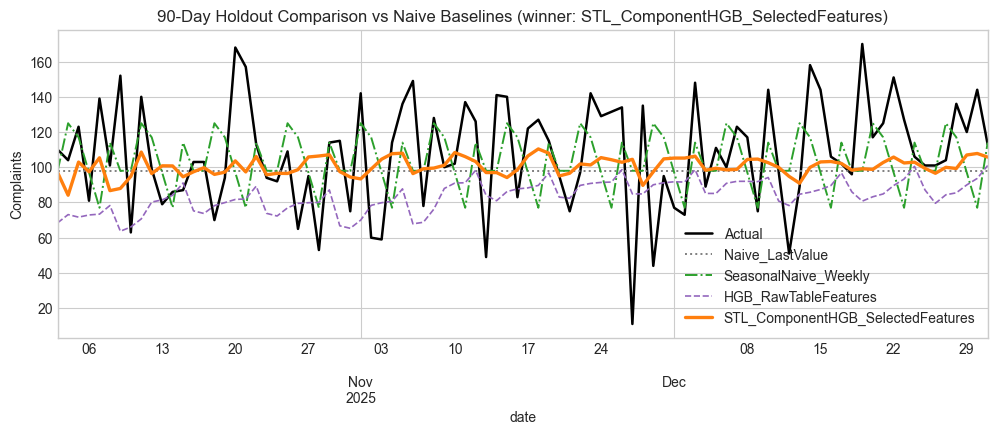

Holdout comparison (baselines + candidates):


,model,role,MAE,RMSE,MAPE_pct
0,STL_ComponentHGB_SelectedFeatures,candidate,24.085057,30.931106,32.481425
1,Naive_LastValue,baseline,25.477778,31.882336,32.743210
2,SeasonalNaive_Weekly,baseline,26.366667,33.986353,34.606587
3,HGB_RawTableFeatures,candidate,31.545953,38.783123,34.404414


MAE         24.085057
RMSE        30.931106
MAPE_pct    32.481425
Name: 0, dtype: float64

In [15]:
pred_map = {
    'Naive_LastValue': pred_naive,
    'SeasonalNaive_Weekly': pred_snaive,
    'HGB_RawTableFeatures': pred_raw_hgb,
    'STL_ComponentHGB_SelectedFeatures': pred_component_hgb,
}
plot_styles = {
    'Naive_LastValue': dict(color='tab:gray', linestyle=':', linewidth=1.4),
    'SeasonalNaive_Weekly': dict(color='tab:green', linestyle='-.', linewidth=1.4),
    'HGB_RawTableFeatures': dict(color='tab:purple', linestyle='--', linewidth=1.2),
    'STL_ComponentHGB_SelectedFeatures': dict(color='tab:orange', linestyle='-', linewidth=2.2),
}
valid_pred = pred_map[winner_name].reindex(valid.index)
metrics = comparison.loc[comparison['model'] == winner_name, ['MAE', 'RMSE', 'MAPE_pct']].iloc[0].astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
valid.plot(ax=ax, label='Actual', color='black', linewidth=1.8)
for name, pred in pred_map.items():
    style = dict(plot_styles[name])
    if name == winner_name:
        style['linewidth'] = 2.4
    pred.reindex(valid.index).plot(ax=ax, label=name, **style)
ax.set_title(f'90-Day Holdout Comparison vs Naive Baselines (winner: {winner_name})')
ax.set_ylabel('Complaints')
ax.legend()
plt.show()

print('Holdout comparison (baselines + candidates):')
display(comparison)
metrics

### 180-day holdout (robustness check)

The production winner stays the **90-day** candidate. This cell repeats the same four models on a longer 180-day window (2025-07-05 to 2025-12-31) so we can see whether the ranking is only a short-window artefact.

This is **not** independent rolling-origin backtesting: the 180-day window contains the 90-day window.

In [ ]:
# Same four models, 180-day holdout. Does not overwrite the 90-day winner.
horizon_180 = 180
train_180 = target.iloc[:-horizon_180]
valid_180 = target.iloc[-horizon_180:]
exog_train_180 = exog_all.loc[train_180.index]

pred_naive_180 = naive_forecast(train_180, horizon=horizon_180)
pred_snaive_180 = seasonal_naive_forecast(train_180, horizon=horizon_180, season=7)
pred_raw_hgb_180 = hgb_raw_table_forecast(train_180, exog_hist=exog_train_180, horizon=horizon_180)
pred_component_hgb_180, *_ = component_hgb_forecast(
    train_180,
    exog_hist=exog_train_180,
    horizon=horizon_180,
    period=7,
    top_n=8,
)

pred_map_180 = {
    'Naive_LastValue': pred_naive_180,
    'SeasonalNaive_Weekly': pred_snaive_180,
    'HGB_RawTableFeatures': pred_raw_hgb_180,
    'STL_ComponentHGB_SelectedFeatures': pred_component_hgb_180,
}

comparison_180 = pd.DataFrame(
    [
        {'model': name, 'role': ('baseline' if 'Naive' in name else 'candidate'), **score_forecast(valid_180, pred)}
        for name, pred in pred_map_180.items()
    ]
).sort_values('MAE').reset_index(drop=True)

winner_180 = (
    comparison_180.loc[comparison_180['role'] == 'candidate']
    .sort_values('MAE')
    .iloc[0]['model']
)
best_naive_mae_180 = float(comparison_180.loc[comparison_180['role'] == 'baseline', 'MAE'].min())
winner_mae_180 = float(comparison_180.loc[comparison_180['model'] == winner_180, 'MAE'].iloc[0])

print(
    f'180-day window: {valid_180.index.min().date()} to {valid_180.index.max().date()} '
    f'(n={len(valid_180)})'
)
print(f'Winner by 180-day MAE (candidates): {winner_180}')
print(
    f'Winner MAE vs best naive: {winner_mae_180:.2f} vs {best_naive_mae_180:.2f} '
    f'(delta={best_naive_mae_180 - winner_mae_180:.2f})'
)

fig, ax = plt.subplots(figsize=(12, 4))
valid_180.plot(ax=ax, label='Actual', color='black', linewidth=1.8)
for name, pred in pred_map_180.items():
    style = dict(plot_styles[name])
    if name == winner_180:
        style['linewidth'] = 2.4
    pred.reindex(valid_180.index).plot(ax=ax, label=name, **style)
ax.set_title(f'180-Day Holdout Comparison vs Naive Baselines (winner: {winner_180})')
ax.set_ylabel('Complaints')
ax.legend()
plt.tight_layout()
holdout_180_png = RESULTS_DIR / 'holdout_comparison_180d.png'
try:
    fig.savefig(holdout_180_png, dpi=150, bbox_inches='tight')
except PermissionError:
    holdout_180_png = RESULTS_DIR / 'holdout_comparison_180d_copy.png'
    fig.savefig(holdout_180_png, dpi=150, bbox_inches='tight')
    print(f'Plot file locked, wrote {holdout_180_png.name} instead')
plt.show()

print('180-day holdout comparison (baselines + candidates):')
display(comparison_180)
print(f'Saved plot: {holdout_180_png}')

side_by_side = (
    comparison.assign(horizon_days=90)[['horizon_days', 'model', 'role', 'MAE', 'RMSE', 'MAPE_pct']]
    .merge(
        comparison_180.assign(horizon_days=180)[['model', 'MAE', 'RMSE', 'MAPE_pct']],
        on='model',
        suffixes=('_90d', '_180d'),
    )
    .drop(columns='horizon_days')
    .sort_values('MAE_90d')
    .reset_index(drop=True)
)
print('90-day vs 180-day MAE/RMSE/MAPE:')
display(side_by_side)

In [16]:
# Retrain winner on all history, then forecast the next 90 days.
# Always build STL component forecast so residual bootstrap can restore fluctuation.
stl_point, component_future_forecast, _, final_component_features = component_hgb_forecast(
    target,
    exog_hist=exog_all.loc[target.index],
    horizon=90,
    period=7,
    top_n=8,
)
print('Final component-model selected features:')
for component, features in final_component_features.items():
    print(f'- {component}: {", ".join(features)}')

if winner_name == 'HGB_RawTableFeatures':
    future_pred = hgb_raw_table_forecast(target, exog_hist=exog_all.loc[target.index], horizon=90)
else:
    future_pred = stl_point

forecast_df = future_pred.to_frame(name='predicted_complaints')
forecast_df.index.name = 'date'
forecast_df['model'] = winner_name
forecast_df.head()


Final component-model selected features:
- tendency: roll7_mean, roll28_mean, time_idx, roll28_std, lag_1, staffing_level_fte_lag1, doy_cos, lag_7
- period: dow_cos, lag_7, dow_sin, lag_14, mom_1_7, is_weekend_lag1, pct_change_7, is_weekend
- noise: lag_7, lag_14, roll7_mean, mom_1_7, lag_1, doy_cos, roll28_mean, is_weekend


,predicted_complaints,model
date,,
2026-01-01,107.137362,STL_ComponentHGB_SelectedFeatures
2026-01-02,113.906445,STL_ComponentHGB_SelectedFeatures
2026-01-03,117.148887,STL_ComponentHGB_SelectedFeatures
2026-01-04,122.427212,STL_ComponentHGB_SelectedFeatures
2026-01-05,127.548131,STL_ComponentHGB_SelectedFeatures


In [182]:
# Residual bootstrap: add historical residual noise back onto the STL structure.
# Keep the deterministic forecast for planning; use the fluctuated band for day-to-day uncertainty.
# (No intermediate sample-path plot — only the final stakeholder figure is shown next.)
fluctuated_paths, fluctuated_summary, vol_scale = generate_residual_bootstrap_paths(
    history=target,
    component_forecast=component_future_forecast,
    n_paths=30,
    random_state=42,
)

print(f'Residual bootstrap vol_scale={vol_scale:.3f}')
hist_delta_std = float(target.diff().std())
det_delta_std = float(fluctuated_summary['deterministic_forecast'].diff().std())
fluc_delta_std = float(fluctuated_summary['fluctuated_p50'].diff().std())
print(
    f'Daily-change std | history={hist_delta_std:.2f} | '
    f'deterministic={det_delta_std:.2f} | fluctuated_median={fluc_delta_std:.2f}'
)
display(fluctuated_summary.head())


Residual bootstrap vol_scale=2.000
Daily-change std | history=27.20 | deterministic=9.01 | fluctuated_median=9.82


,deterministic_forecast,fluctuated_mean,fluctuated_p10,fluctuated_p50,fluctuated_p90
date,,,,,
2026-01-01,107.137362,105.444677,97.409133,106.156602,117.230064
2026-01-02,113.906445,113.639403,45.687833,110.539677,168.923075
2026-01-03,117.148887,123.955917,103.839579,117.770686,179.462465
2026-01-04,122.427212,118.496310,57.888680,123.324135,140.105516
2026-01-05,127.548131,122.877915,72.609663,126.031333,135.239685


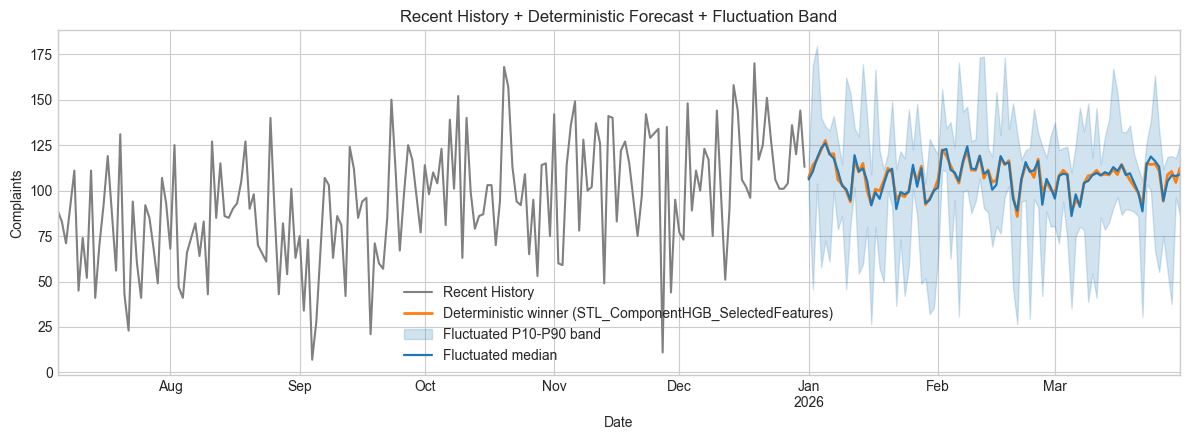

Forecast file saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\complaints_forecast_next_90_days.csv
Metrics file saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\holdout_metrics.csv
Comparison file saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\model_comparison.csv
Component forecast file saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\stl_component_forecast_next_90_days.csv
Fluctuated paths saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\forecast_fluctuated_paths.csv
Fluctuated summary saved to: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Technical-Assessment-LiyuanLIU\results\forecast_fluctuated_summary.csv
Forecast plot saved to: C:\Users\liyuan.liu\OneDrive - CPI\Lear

In [17]:
# Save deliverables and plot the single stakeholder forecast figure
forecast_csv = RESULTS_DIR / 'complaints_forecast_next_90_days.csv'
metrics_csv = RESULTS_DIR / 'holdout_metrics.csv'
comparison_csv = RESULTS_DIR / 'model_comparison.csv'
comparison_180_csv = RESULTS_DIR / 'model_comparison_180d.csv'
component_forecast_csv = RESULTS_DIR / 'stl_component_forecast_next_90_days.csv'
fluctuated_paths_csv = RESULTS_DIR / 'forecast_fluctuated_paths.csv'
fluctuated_summary_csv = RESULTS_DIR / 'forecast_fluctuated_summary.csv'
forecast_plot_png = RESULTS_DIR / 'forecast_with_fluctuation_band.png'


def save_csv(df, path, **kwargs):
    """Write CSV; if OneDrive/Excel has the file locked, fall back to *_copy.csv."""
    try:
        df.to_csv(path, **kwargs)
        return path
    except PermissionError:
        fallback = path.with_name(f'{path.stem}_copy{path.suffix}')
        df.to_csv(fallback, **kwargs)
        print(f'File locked, wrote {fallback.name} instead of {path.name}')
        return fallback


# Re-run bootstrap here if this cell is executed before the previous one.
if 'fluctuated_paths' not in globals() or 'fluctuated_summary' not in globals():
    fluctuated_paths, fluctuated_summary, vol_scale = generate_residual_bootstrap_paths(
        history=target,
        component_forecast=component_future_forecast,
        n_paths=30,
        random_state=42,
    )

forecast_csv = save_csv(forecast_df, forecast_csv)
metrics_csv = save_csv(metrics.to_frame(name='value'), metrics_csv)
comparison_csv = save_csv(comparison, comparison_csv, index=False)
if 'comparison_180' in globals():
    comparison_180_csv = save_csv(comparison_180, comparison_180_csv, index=False)
component_forecast_csv = save_csv(component_future_forecast, component_forecast_csv)
fluctuated_paths_csv = save_csv(fluctuated_paths, fluctuated_paths_csv)
fluctuated_summary_csv = save_csv(fluctuated_summary, fluctuated_summary_csv)

fig, ax = plt.subplots(figsize=(12, 4.5))
target.tail(180).plot(ax=ax, label='Recent History', color='gray')
forecast_df['predicted_complaints'].plot(
    ax=ax, label=f'Deterministic winner ({winner_name})', color='tab:orange', linewidth=2
)
ax.fill_between(
    fluctuated_summary.index,
    fluctuated_summary['fluctuated_p10'],
    fluctuated_summary['fluctuated_p90'],
    color='tab:blue',
    alpha=0.2,
    label='Fluctuated P10-P90 band',
)
fluctuated_summary['fluctuated_p50'].plot(
    ax=ax, label='Fluctuated median', color='tab:blue', linewidth=1.6
)
ax.set_title('Recent History + Deterministic Forecast + Fluctuation Band')
ax.set_ylabel('Complaints')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
try:
    fig.savefig(forecast_plot_png, dpi=150, bbox_inches='tight')
except PermissionError:
    forecast_plot_png = RESULTS_DIR / 'forecast_with_fluctuation_band_copy.png'
    fig.savefig(forecast_plot_png, dpi=150, bbox_inches='tight')
    print(f'Plot file locked, wrote {forecast_plot_png.name} instead')
plt.show()

print(f'Forecast file saved to: {forecast_csv}')
print(f'Metrics file saved to: {metrics_csv}')
print(f'Comparison file saved to: {comparison_csv}')
if 'comparison_180' in globals():
    print(f'180-day comparison file saved to: {comparison_180_csv}')
print(f'Component forecast file saved to: {component_forecast_csv}')
print(f'Fluctuated paths saved to: {fluctuated_paths_csv}')
print(f'Fluctuated summary saved to: {fluctuated_summary_csv}')
print(f'Forecast plot saved to: {forecast_plot_png}')



### Final forecast figure

**What the plot shows**
- **Grey:** recent actual complaints (noisy history).
- **Orange:** deterministic 90-day planning forecast from the holdout winner.
- **Blue median + P10–P90 band:** residual-bootstrap uncertainty around that same structure.

**What P10–P90 means**
- For each future day, many fluctuated scenarios are generated by resampling historical residual noise.
- **P10** = lower end (about 10% of scenarios fall below it).
- **P90** = upper end (about 10% of scenarios fall above it).
- The shaded band is the range containing roughly the middle **80%** of scenario paths.
- It is a practical uncertainty envelope, not a formal statistical prediction interval or a guaranteed min/max.

**How to explain it**
- Orange = what we plan for (tendency + period + modelled structure).
- Blue band = day-to-day fluctuation can still look like history, even when the plan is stable.
- Use orange for capacity planning; use the band to communicate uncertainty.

## Final Findings

### What the data told us
- Daily complaints (2023–2025) are noisy and high-frequency (mean ≈ 80, CV ≈ 0.31).
- There is clear weekly seasonality (lag-7 autocorr ≈ 0.41; Mon–Wed higher than Thu/Fri).
- The medium-term level drifts over time (winter higher than summer), increasing with year.
- Operational drivers (staffing, backlog) matter moderately; `centered_7d_mean` looks strong but leaks future information, so it was excluded from modelling. However it helps to introduce the derived features such as roll7_mean etc. 

### Modelling approach
- STL decomposition separated complaints into **tendency**, **period**, and **noise**.
- Each component was modelled with its own top correlated causal features (e.g. `roll28_mean` for tendency; `dow_sin`/`dow_cos` for period).
- This was compared against **naive baselines** (last-value and weekly seasonal naive) and against a direct HGB using only raw-table lag-1 features + calendar (no STL).

### Holdout result (last 90 days)
| Model | MAE | RMSE | MAPE | Role |
| --- | ---: | ---: | ---: | --- |
| **STL_ComponentHGB_SelectedFeatures (winner)** | **24.1** | **30.9** | **32.5%** | candidate |
| Naive_LastValue | 25.5 | 31.9 | 32.7% | baseline |
| SeasonalNaive_Weekly | 26.4 | 34.0 | 34.6% | baseline |
| HGB_RawTableFeatures | 31.5 | 38.8 | 34.4% | candidate |

- STL component modelling is the best *candidate* and does beat both naive baselines, but the margin is modest: about **1.4 MAE** vs last-value naive and **2.3 MAE** vs weekly seasonal naive.
- The raw-table HGB does **not** beat either naive baseline on this holdout.
- Point forecasts remain smoother than history because residual noise is only partly predictable.

### Holdout result (last 180 days)
| Model | MAE | RMSE | MAPE | Role |
| --- | ---: | ---: | ---: | --- |
| **STL_ComponentHGB_SelectedFeatures** | **24.4** | **30.9** | **42.0%** | candidate |
| HGB_RawTableFeatures | 26.2 | 32.8 | 40.4% | candidate |
| Naive_LastValue | 29.5 | 36.2 | 41.6% | baseline |
| SeasonalNaive_Weekly | 30.2 | 37.0 | 45.9% | baseline |

- STL is still the best candidate on the longer window, with a **larger** gap vs last-value naive (~5.1 MAE) than on 90 days.
- Raw-table HGB **does** beat both naive baselines on 180 days (it did not on 90 days), so that 90-day failure looks window-specific.
- Production winner remains the **90-day** STL candidate; 180 days is a robustness check only. The 180-day window contains the 90-day window, so these are not independent tests.

### Final 90-day forecast
- Winner model was retrained on all history and used for the next 90 days.
- Deterministic forecast (orange) = planning path from tendency + period + modelled structure.
- Residual bootstrap adds historical residual noise back to produce a fluctuated median and **P10–P90** uncertainty band.
- **Use orange for capacity planning; use the blue band to communicate day-to-day uncertainty.**
- The holdout ranking and the uncertainty band should be read with the **Limitations** section below.

## Limitations

These are known gaps in this assessment and should be read alongside the holdout table.

### Single holdout split
The production winner is still chosen on **one** 90-day window (2025-10-03 to 2025-12-31). A 180-day holdout is included as a robustness check, and STL still wins there, but that longer window **contains** the 90-day window, so it is not an independent test. Rolling-origin backtesting (even 3–4 folds) is the standard check and is not done here. Treat the ranking as indicative, not as a confirmed superiority result.

### Uncertainty band understates uncertainty
The residual-bootstrap P10–P90 band is a communication device, not a calibrated prediction interval:
- Residuals are resampled **i.i.d.**, which ignores their autocorrelation.
- Only **30** paths are used to estimate P10/P90, so the quantile estimates are noisy.
- The band **does not widen with horizon**. Real 90-day-ahead uncertainty grows; this band is about as narrow at day 90 as at day 1.
- There is **no model or trend uncertainty** — only residual noise around a fixed structure.
- `vol_scale` divides the standard deviation of **daily differences** by the standard deviation of **residual levels**. For a noisy series the difference-std is typically about √2 larger, so the scale is systematically inflated: it compares two different quantities.

### Known future information is discarded
Bank holidays in the forecast window are knowable in advance, but the component model persists the last observed holiday flag rather than using a future calendar. A New Year's Day sitting at the start of this exact 90-day forecast window (2026-01-01) therefore goes unmodelled.

### Recursive self-feeding
Both candidate models append their own predictions to history and recompute rolling features from those predictions. Because predictions are smoother than reality, volatility features (`roll7_std`, `roll28_std`) decay toward zero over the horizon. The residual bootstrap is essentially a patch for that artifact; it is applied rather than diagnosed (for example by tracking how rolling-std features evolve along the recursive path).